In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Ostfalia Hochschule für Angewandte Wissenschaften' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202603` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202603` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/01bk10867' -- 'Ostfalia Hochschule für Angewandte Wissenschaften'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Ostfalia Hochschule für Angewandte Wissenschaften,"Department of Computer Science, Ostfalia Unive...",https://openalex.org/W4283327233
1,not assigned,Ostfalia Hochschule für Angewandte Wissenschaften,"Faculty of Computer Science, Ostfalia Universi...",https://openalex.org/W4214577756
2,not assigned,Ostfalia Hochschule für Angewandte Wissenschaften,Ostfalia Hochschule für angewandte Wissenschaf...,https://openalex.org/W4310022065
3,not assigned,Ostfalia Hochschule für Angewandte Wissenschaften,Ostfalia Hochschule für angewandte Wissenschaf...,https://openalex.org/W4220993786
4,not assigned,Ostfalia Hochschule für Angewandte Wissenschaften,"Institute for Information Engineering, Ostfali...",https://openalex.org/W4282938772


In [24]:
MAPPING_DICT = {
    'Fakultät Bau-Wasser-Boden': ['bau-wasser-boden', 'civil engineering', 'enviro(n)?mental engineering', 'civil department'],
    'Fakultät Handel und Soziale Arbeit': ['trade and social work'],
    'Fakultät Verkehr-Sport-Tourismus-Medien': ['media management', 'tourism-media', 'public communication', 'regionalforschung'],
    'Fakultät Elektro- und Informationstechnik': ['electrical (engineering|energy|systems)'],
    'Fakultät Informatik': ['information engineering', 'informatik', 'computer science', 'robotics lab', 'distributed systems', 
                            'faculty for( applied)? informatics', 'applied informatics'],
    'Fakultät Maschinenbau': ['mechatroni(k|cs)', 'mechanical engineering', 'production technolog(y|ies)', 'maschinenbau'],
    'Fakultät Recht': ['economic law', '(bels)', 'institut für recht', 'brunswick european law'],
    'Fakultät Soziale Arbeit': ['soziale(n)? arbeit', 'social work'],
    'Fakultät Versorgungstechnik': ['biotechnology', 'kommunikationssysteme', 'supply (engineering|technology)', 'versorgungstechnik', 'communication systems'],
    'Fakultät Fahrzeugtechnik': ['recycling', 'vehicle', 'automotive engineering', 'fahrzeugbau'],
    'Fakultät Gesundheitswesen': ['health(\s)?(care|science|service)', 'gesundheit'],
    'Fakultät Wirtschaft': ['fakultät wirtschaft', 'faculty of business', 'business administration']
}

In [25]:
with open('./mapping_tables_fak/ostfalia.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [26]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [27]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [28]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,Fakultät Informatik,Ostfalia Hochschule für Angewandte Wissenschaften,"Department of Computer Science, Ostfalia Unive...",https://openalex.org/W4283327233
1,Fakultät Informatik,Ostfalia Hochschule für Angewandte Wissenschaften,"Faculty of Computer Science, Ostfalia Universi...",https://openalex.org/W4214577756
2,None,Ostfalia Hochschule für Angewandte Wissenschaften,Ostfalia Hochschule für angewandte Wissenschaf...,https://openalex.org/W4310022065
3,None,Ostfalia Hochschule für Angewandte Wissenschaften,Ostfalia Hochschule für angewandte Wissenschaf...,https://openalex.org/W4220993786
4,Fakultät Informatik,Ostfalia Hochschule für Angewandte Wissenschaften,"Institute for Information Engineering, Ostfali...",https://openalex.org/W4282938772
...,...,...,...,...
607,Fakultät Recht,Ostfalia Hochschule für Angewandte Wissenschaften,"Brunswick European Law School (BELS), Ostfalia...",https://openalex.org/W3187365485
608,Fakultät Informatik,Ostfalia Hochschule für Angewandte Wissenschaften,"Department of Computer Science, Ostfalia Unive...",https://openalex.org/W3196278405
609,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,Ostfalia Hochschule für angewandte Wissenschaf...,https://openalex.org/W4244938012
610,None,Ostfalia Hochschule für Angewandte Wissenschaften,"Redaktionskomitee, Prof. Dr., GNP, ...",https://openalex.org/W3082053184


In [29]:
df_with_inst[(df_with_inst.fak_name.isnull()) & df_with_inst.raw_affiliation_string.str.contains('ostfalia', case=False, regex=False)].raw_affiliation_string.unique()

array(['Ostfalia Hochschule für angewandte Wissenschaften, Ostfalia HaW, 38302, Wolfenbüttel, Germany',
       'Ostfalia Hochschule für angewandte Wissenschaften (Germany)',
       'Ostfalia Hochschule für angewandte Wissenschaften, Wolfsburg, Deutschland',
       'Ostfalia Hochschule für angewandte Wissenschaften - Hochschule Braunschweig/Wolfenbüttel, Wolfsburg, Deutschland',
       'Ostfalia Hochschule, Wolfsburg, Deutschland',
       'Ostfalia University of Applied Sciences',
       'Ostfalia University of Applied Sciences, Herbert-Meyer-Straße 7, 29556, Suderburg, Germany',
       'Ostfalia Hochschule für angewandte Wissenschaften',
       'Ostfalia University of applied sciences, Salzdahlumer Straße 46/48, 38302 Wolfenbüttel, Germany',
       'Ostfalia Hochschule für angewandte Wissenschaften , Siegfried-Ehlers-Straße 1 , Wolfsburg Germany',
       'Ostfalia Hochschule für angewandte Wissenschaften, Rothenfelder Straße 10, 38440 Wolfsburg, Deutschland',
       'Ostfalia Hochschul

In [30]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Fakultät Bau-Wasser-Boden,11
1,Fakultät Elektro- und Informationstechnik,40
2,Fakultät Fahrzeugtechnik,16
3,Fakultät Gesundheitswesen,56
4,Fakultät Handel und Soziale Arbeit,5
5,Fakultät Informatik,152
6,Fakultät Maschinenbau,69
7,Fakultät Recht,16
8,Fakultät Soziale Arbeit,21
9,Fakultät Verkehr-Sport-Tourismus-Medien,10


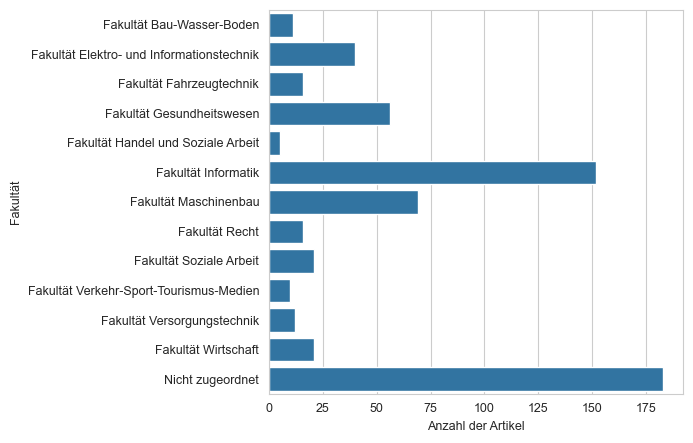

In [31]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [32]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.7009803921568627

In [33]:
MAPPING_DICT_DEPT = {
    'Fakultät Verkehr-Sport-Tourismus-Medien': {
        'Institut für Mediendesign (IMD)': ['mediendesign'],
        'Institut für Medienmanagement': ['medienmanagement', 'media management'],
        'Institut für Verkehrsmanagement': ['verkehrsmanagement'],
        'Institut für Öffentliche Kommunikation (IÖK)': ['öffentliche kommunikation', 'public communication'],
    },
    'Fakultät Elektro- und Informationstechnik': {
        'Institut für Elektrische Anlagen und Automatisierungstechnik (IfEA)': ['automatisierungstechnik', 'process engineering', 
                                                                                'automation (technology|system)'
                                                                               ],
    },
    'Fakultät Informatik': {
        'Institut für Information Engineering (IIE)': ['information engineering'],
        'Institut für Medieninformatik und Online-Lehre (IMI)': ['medieninformatik'],
        'Institut für Software Engineering (ISE)': ['software engineering'],
        'Institut für Verteilte Systeme (IVS)': ['verteilte systeme', 'distributed system'],
    },
    'Fakultät Maschinenbau': {
        'Institut für Konstruktion und Angewandten Maschinenbau': ['konstruktion', 'design and applied'],
        'Institut für Mechatronik': ['mechatroni(k|c)'],
        'Institut für Produktionstechnik': ['produktionstechnik', 'production technolog(y|ies)'],
    },
    'Fakultät Recht': {
        'Institut für Europäisches und Internationales Wirtschaftsrecht': ['international economic law'],
        'Institut für Finanzen, Steuern und Recht': ['finanzen', 'finance'],
        #'Institut für Geistiges Eigentum, Recht und Wirtschaft in der Informationsgesellschaft': [],
        'Institut für Personalmanagement und Recht': ['personalmanagement'],
    },
    'Fakultät Soziale Arbeit': {
        #'Institut für angewandte Rechts- und Sozialforschung (IRS)': [],
        #'Professur Digitaliät in Rehabilitation und Teilhabe': [],
    },
    'Fakultät Versorgungstechnik': {
        'Institut für Biotechnologie und Umweltforschung (IBU)': ['biotechnolog(ie|y)'],
        #'Institut für energieoptimierte Systeme': [],
        #'Institut für Technische Unternehmensführung': [],
        'Institut für Kommunikationssysteme und Technologien': ['kommunikationssysteme', 'communication systems'],
    },
    'Fakultät Fahrzeugtechnik': {
        'Institut für Fahrzeugbau Wolfsburg (IFBW)': ['fahrzeugbau', 'vehicle body'],
        #'Institut für Fahrzeuginformatik und Fahrzeugelektronik': [],
        'Institut für Recycling': ['recycling'],
    }
}

In [34]:
with open('./mapping_tables_dept/ostfalia.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [35]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [36]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät Fahrzeugtechnik', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fakultät Fahrzeugtechnik']['raw_affiliation_string'].apply(map_dept, 
                                                                                                    faculty='Fakultät Fahrzeugtechnik')

In [37]:
df_with_inst[(df_with_inst['fak_name'] == 'Fakultät Fahrzeugtechnik') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[0:]

array(['Ostfalia University of Applied Sciences,Faculty of Automotive Engineering,Wolfsburg,Germany',
       'Faculty of Automotive Engineering, Ostfalia University of Applied Sciences, Robert-Koch-Platz 8A, 38440 Wolfsburg, Germany',
       'Faculty of Automotive Engineering, Ostfalia University of Applied Sciences, Kleiststraße 26, 38440 Wolfsburg, Germany',
       'IFA, Faculty of Automotive Engineering, Ostfalia UAS, Wolfsburg, Germany',
       'Faculty of Automotive Engineering, Ostfalia University of Applied Sciences, Wolfsburg, Germany',
       'Faculty of Automotive Engineering, Ostfalia University of Applied Sciences, Kleiststr. 14-16, D-38440 Wolfsburg, Germany'],
      dtype=object)

In [38]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät Fahrzeugtechnik'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Institut für Fahrzeugbau Wolfsburg (IFBW),2
1,Institut für Recycling,8
2,NaN,6


In [39]:
df_with_inst[df_with_inst['fak_name'] == 'Fakultät Fahrzeugtechnik']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
28,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,"Ostfalia University of Applied Sciences,Facult...",https://openalex.org/W4313263318,None
68,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,"Institut für Fahrzeugbau (IFBW), Ostfalia Univ...",https://openalex.org/W4214680642,Institut für Fahrzeugbau Wolfsburg (IFBW)
121,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,"Faculty of Automotive Engineering, Ostfalia Un...",https://openalex.org/W4403325497,None
143,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,"Faculty of Automotive Engineering, Ostfalia Un...",https://openalex.org/W4392709861,None
195,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,"Institute of Recycling, Ostfalia University of...",https://openalex.org/W4411358419,Institut für Recycling
214,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,"Institute of Recycling, Ostfalia University of...",https://openalex.org/W4410556673,Institut für Recycling
229,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,"Institute for Recycling, Ostfalia University o...",https://openalex.org/W4406680069,Institut für Recycling
247,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,Vehicle Body Engineering and Lightweight Desig...,https://openalex.org/W4416367789,Institut für Fahrzeugbau Wolfsburg (IFBW)
257,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,"Institute of Recycling, Ostfalia University of...",https://openalex.org/W4414111179,Institut für Recycling
330,Fakultät Fahrzeugtechnik,Ostfalia Hochschule für Angewandte Wissenschaften,"Ostfalia University of Applied Sciences, Insti...",https://openalex.org/W4385955985,Institut für Recycling


In [40]:
MAPPING_DICT_INST = {}

In [41]:
gerit_ids = pd.read_csv('../../data/gerit_inst_with_ids.csv')
gerit_ids = gerit_ids[gerit_ids.parent_name == 'Ostfalia Hochschule für angewandte Wissenschaften'][['inst_name', 'dfg_id']].to_dict(orient='records')

def search_gerit_id(name: str):  
    for gerit_id in gerit_ids:
        if gerit_id['inst_name'] == name:
            return gerit_id.get('dfg_id')

uni_dicts = dict()

for faculty, faculty_patterns in MAPPING_DICT.items():

    faculty_dict = dict()

    faculty_dict['faculty_id'] = search_gerit_id(faculty)
    faculty_dict['faculty_patterns'] = faculty_patterns

    faculty_suborganisations = dict()
    
    if MAPPING_DICT_DEPT.get(faculty):
        for department, department_patterns in MAPPING_DICT_DEPT.get(faculty).items():

            department_dict = dict()
            
            department_dict['department_id'] = search_gerit_id(department)
            department_dict['department_patterns'] = department_patterns

            department_suborganisations = dict()
            
            if MAPPING_DICT_INST.get(department):
                for institute, institute_patterns in MAPPING_DICT_INST.get(department).items():

                    institute_dict = dict()
            
                    institute_dict['institute_id'] = search_gerit_id(institute)
                    institute_dict['institute_patterns'] = institute_patterns

                    department_suborganisations[institute] = institute_dict
                    
            department_dict['suborganisations'] = department_suborganisations

            faculty_suborganisations[department] = department_dict

    faculty_dict['suborganisations'] = faculty_suborganisations

    uni_dicts[faculty] = faculty_dict

with open('../../data/mappings/ostfalia.json', mode='w', encoding='utf-8') as f:
    json.dump(uni_dicts, f, ensure_ascii=False)